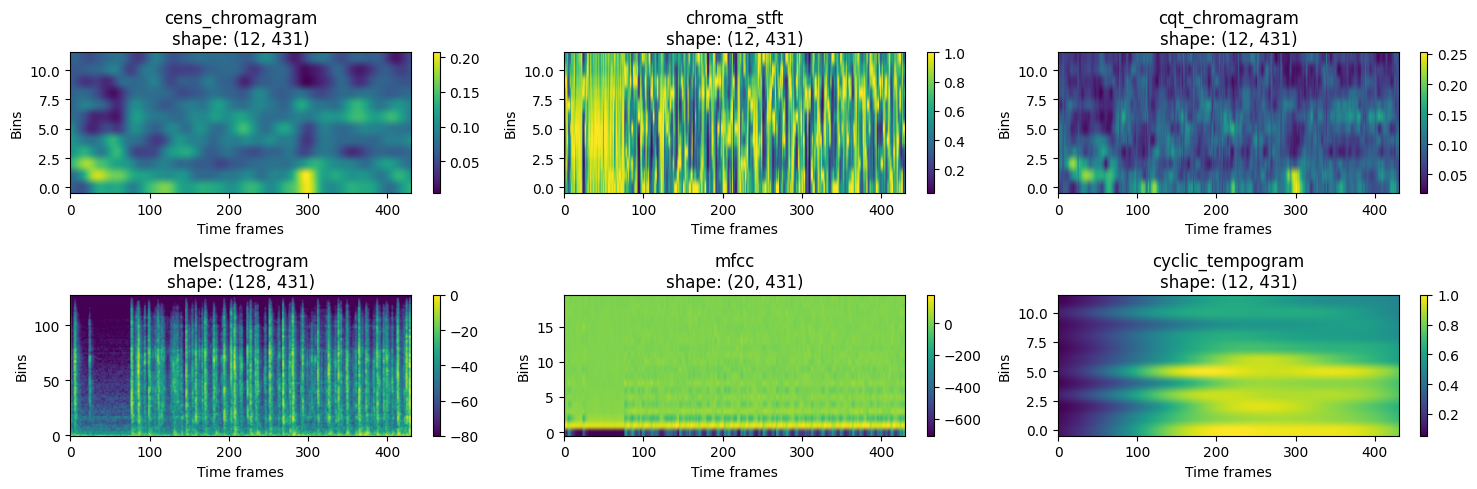

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Cấu hình
base_dir = Path("../../data/features/train")
audio_file_stem = "1-137-A-32"  # Tên file audio không có .wav
feature_names = [
    "cens_chromagram",
    "chroma_stft",
    "cqt_chromagram",
    "melspectrogram",
    "mfcc",
    "cyclic_tempogram"
]

# Tạo subplot
fig, axes = plt.subplots(2, 3, figsize=(15, 5))
axes = axes.flatten()

for ax, fname in zip(axes, feature_names):
    file_path = base_dir / f"{audio_file_stem}_{fname}.npy"
    if not file_path.exists():
        print(f"File not found: {file_path}")
        ax.set_title(f"{fname}\n(not found)")
        ax.axis('off')
        continue
    
    data = np.load(file_path)
    ax.set_title(f"{fname}\nshape: {data.shape}")
    
    if data.ndim == 2:
        im = ax.imshow(data, aspect='auto', origin='lower', cmap='viridis')
        plt.colorbar(im, ax=ax)
        ax.set_xlabel("Time frames")
        ax.set_ylabel("Bins")
    elif data.ndim == 1:
        ax.plot(data)
        ax.set_xlabel("Index")
        ax.set_ylabel("Value")
        ax.grid(True)
    else:
        ax.text(0.5, 0.5, f"Unsupported dim: {data.ndim}", ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()